In [1]:
%load_ext autoreload
%autoreload 2
import os
import numpy as np

from opacus.accountants.analysis.rdp import compute_rdp, get_privacy_spent

from experiments.plotting import make_multiline_plot
from statsmodels.stats.proportion import proportion_confint
from scipy.stats import beta

## Confidence computation given confidence interval and number of samples

In [3]:
# Functions
conf_int = lambda k, n, alpha: proportion_confint(k, n, alpha=alpha, method="beta")
eta = lambda p_ub_lower, p_lb_upper, n, k: beta.cdf(p_lb_upper, k + 1, n - k + 1) - beta.cdf(p_ub_lower, k + 1, n - k + 1)
get_k = lambda n, hit_ratio: int(n * hit_ratio)

In [3]:
# Constants
hit_ratio = 0.95
ns = np.array([10, 20, 30, 50, 75, 100, 150, 200])#, 1500, 2000, 3000, 4000, 5000])
alphas = np.array([0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95])
confidences = np.array([1 - alpha for alpha in alphas])
conf_ints_lb = np.array([[proportion_confint(get_k(n, hit_ratio), n, alpha=alpha, method="beta")[0] for n in ns] for alpha in alphas])
conf_ints_ub = np.array([[proportion_confint(n - get_k(n, hit_ratio), n, alpha=alpha, method="beta")[1] for n in ns] for alpha in alphas])
print(f"Confidence intervals for hit ratio {hit_ratio}:\n{conf_ints_lb}\n{conf_ints_ub}")

Confidence intervals for hit ratio 0.95:
[[0.45571294 0.68285827 0.72599865 0.79729373 0.84145547 0.86485532
  0.88046507 0.89603784]
 [0.55498388 0.75126724 0.7792646  0.83451805 0.86903919 0.88716509
  0.8976181  0.90997246]
 [0.6058367  0.78389384 0.80467396 0.85216282 0.88209974 0.89774662
  0.90582852 0.91666485]
 [0.66315228 0.81903904 0.83218706 0.87124358 0.89623808 0.90922853
  0.91481182 0.92401021]
 [0.70044357 0.84108162 0.84958712 0.88332411 0.90520953 0.91653571
  0.92057869 0.92874123]
 [0.72901185 0.85756765 0.86271236 0.89245795 0.91200951 0.92208893
  0.92499243 0.93237199]
 [0.75262937 0.8709506  0.87346039 0.89995937 0.9176088  0.92667316
  0.92865922 0.93539567]
 [0.77305405 0.88235339 0.88270084 0.90643018 0.92245203 0.93064828
  0.93185785 0.93803938]
 [0.79126133 0.89239    0.89091073 0.9122007  0.9267835  0.93421226
  0.93474234 0.94042877]
 [0.8078571  0.90143667 0.89838417 0.91747504 0.93075451 0.93748801
  0.93740885 0.94264248]
 [0.82325042 0.90974394 0.905

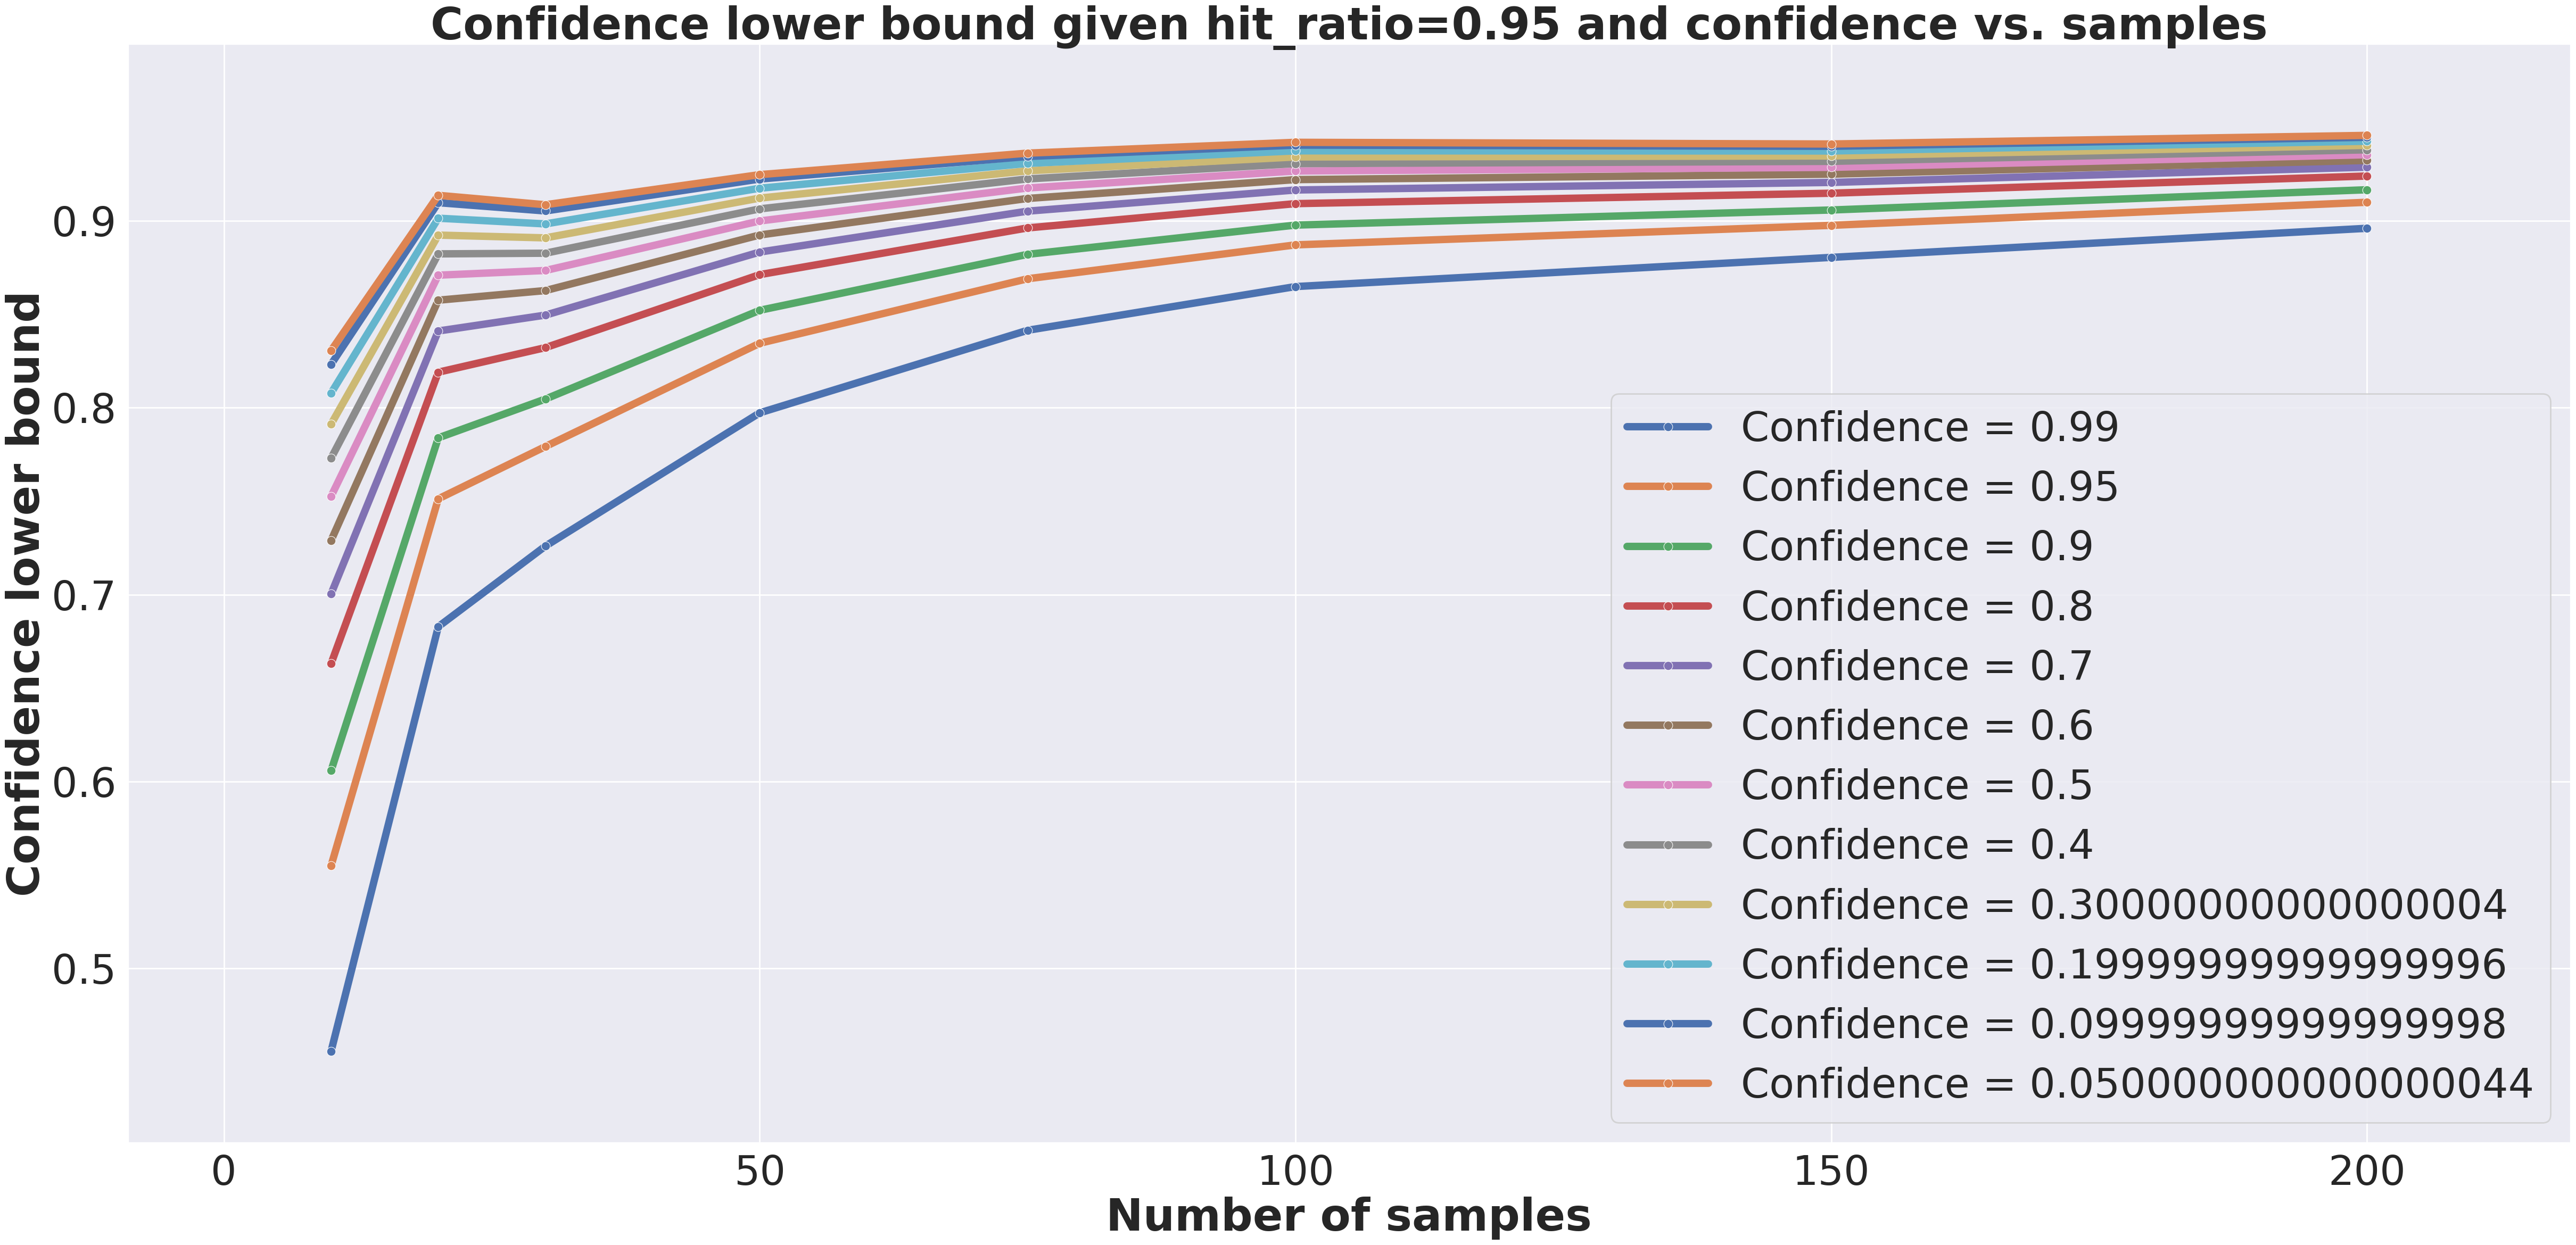

In [4]:
make_multiline_plot(
    ns,
    conf_ints_lb,
    ["Confidence = " + str(confidence) for confidence in confidences],
    "Number of samples",
    f"Confidence lower bound",
    f"Confidence lower bound given hit_ratio={hit_ratio} and confidence vs. samples"
)

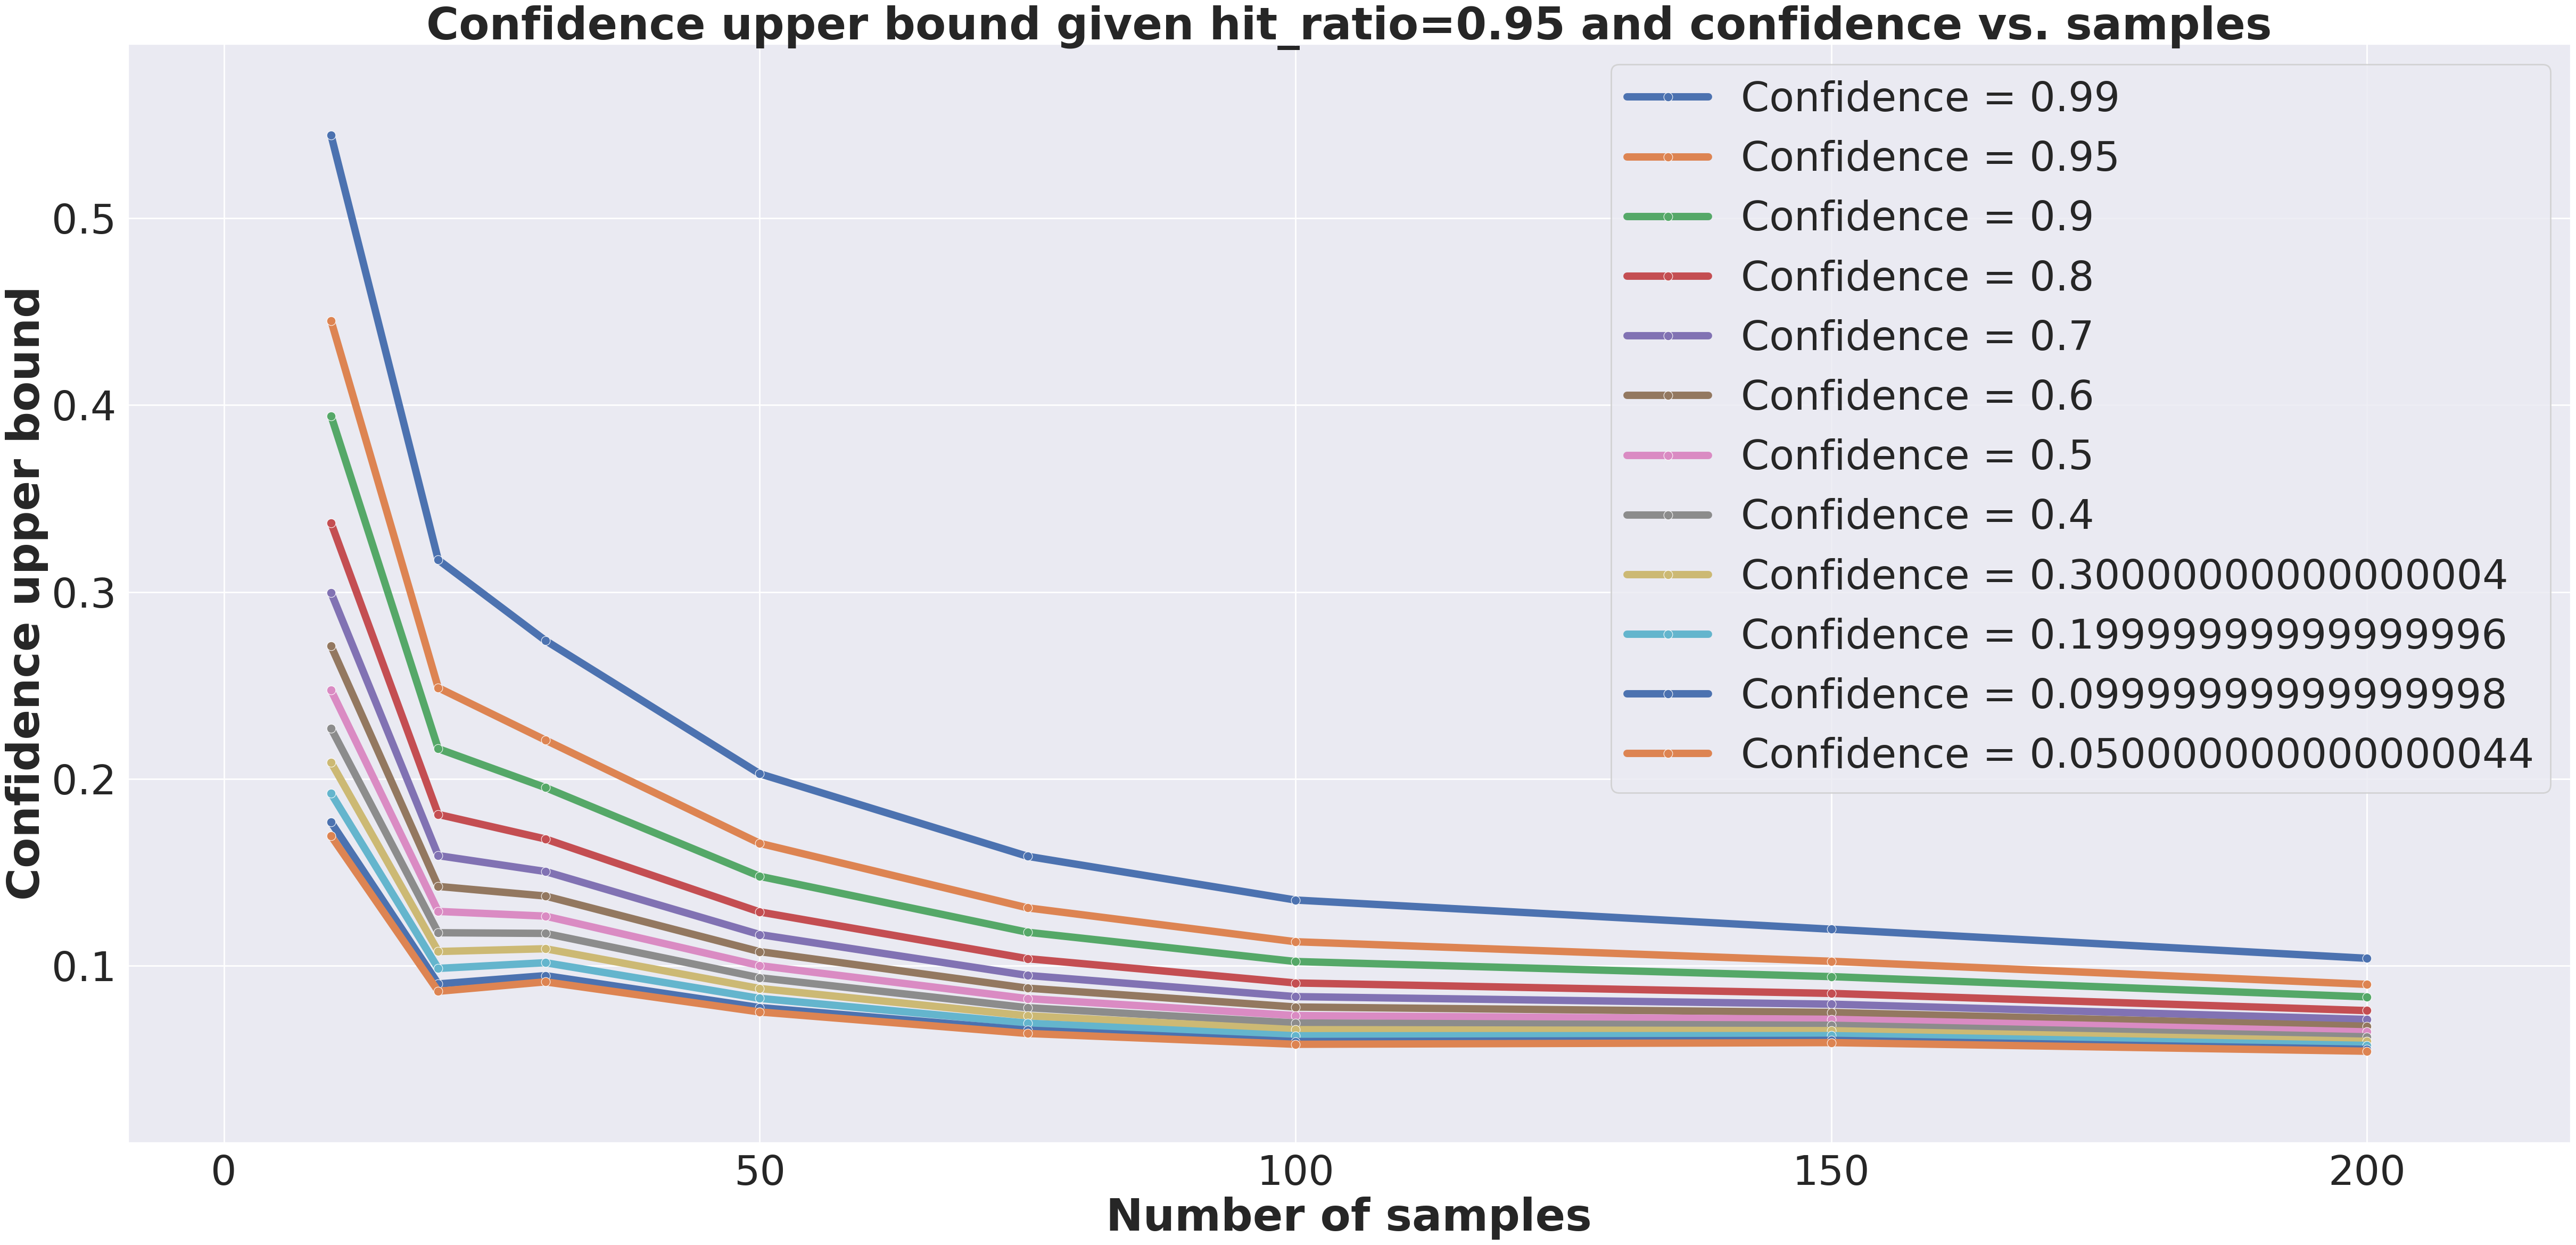

In [5]:
make_multiline_plot(
    ns,
    conf_ints_ub,
    ["Confidence = " + str(confidence) for confidence in confidences],
    "Number of samples",
    f"Confidence upper bound",
    f"Confidence upper bound given hit_ratio={hit_ratio} and confidence vs. samples"
)

In [2]:
def outcome_guarantee(q, alpha, r, steps, sigma, max_grad_norm, p_lb_inside, p_ub_outside) -> bool:
    # Effective sampling probability for r changes
    q_r = 1 - (1 - q) ** r
    noise_multiplier = sigma / max_grad_norm
    eps = compute_rdp(q=q_r, noise_multiplier=noise_multiplier, steps=steps, orders=[alpha])
    exp_eps, exp_minus_eps = 0, 0
    if eps >= np.ceil(np.log(np.finfo(np.float32).max - 1)):
        exp_eps = np.finfo(np.float32).max - 1
        exp_minus_eps = np.array([0])
    else:
        exp_eps = np.exp(eps)
        exp_minus_eps = np.exp(-eps)
    print(f"eps: {eps}, exp_eps: {exp_eps}, exp_minus_eps: {exp_minus_eps}")
    print(f"eps: {eps}")
    k_inv_l = exp_minus_eps * (p_lb_inside ** (alpha / (alpha - 1.0)))
    k_u = (exp_eps * p_ub_outside) ** ((alpha - 1.0) / alpha)

    return float(k_inv_l), float(k_u)

In [19]:
inside_lb = 0.999
outside_ub = 1 - inside_lb
alpha = 1.5
steps = 120
sigma = 0.3
max_grad_norm = 0.6
q = 0.0125

eps: [0], exp_eps: [1.], exp_minus_eps: [1.]
eps: [0]
eps: [0.4728773], exp_eps: [1.60460448], exp_minus_eps: [0.62320654]
eps: [0.4728773]
eps: [1.61320278], exp_eps: [5.01885983], exp_minus_eps: [0.19924844]
eps: [1.61320278]
eps: [3.24800536], exp_eps: [25.73894886], exp_minus_eps: [0.03885163]
eps: [3.24800536]
eps: [5.28358564], exp_eps: [197.07525077], exp_minus_eps: [0.0050742]
eps: [5.28358564]
eps: [7.65371409], exp_eps: [2108.46209065], exp_minus_eps: [0.00047428]
eps: [7.65371409]
eps: [10.30679642], exp_eps: [29935.38236941], exp_minus_eps: [3.34052857e-05]
eps: [10.30679642]
eps: [13.20055978], exp_eps: [540667.50923511], exp_minus_eps: [1.84956555e-06]
eps: [13.20055978]
eps: [16.29933214], exp_eps: [11986986.19320239], exp_minus_eps: [8.34238051e-08]
eps: [16.29933214]
eps: [19.57245344], exp_eps: [3.1637964e+08], exp_minus_eps: [3.16075965e-09]
eps: [19.57245344]
eps: [22.99325668], exp_eps: [9.67931214e+09], exp_minus_eps: [1.03313127e-10]
eps: [22.99325668]
eps: [26.5

/tmp/ipykernel_2846790/968357514.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(k_inv_l), float(k_u)


eps: [41.58383484], exp_eps: [1.14717588e+18], exp_minus_eps: [8.71705915e-19]
eps: [41.58383484]
eps: [45.4848386], exp_eps: [5.67302131e+19], exp_minus_eps: [1.76272914e-20]
eps: [45.4848386]
eps: [49.41686614], exp_eps: [2.8938251e+21], exp_minus_eps: [3.45563386e-22]
eps: [49.41686614]
eps: [53.36989436], exp_eps: [1.50747675e+23], exp_minus_eps: [6.6336015e-24]
eps: [53.36989436]
eps: [57.33503135], exp_eps: [7.94854678e+24], exp_minus_eps: [1.25809161e-25]
eps: [57.33503135]
ks: [(0.997002999, 0.6213387861589106, 0.19865129395711353, 0.03873518706758914, 0.005058996475256826, 0.0004728579201980081, 3.330517000574048e-05, 1.8440224018833271e-06, 8.317378387950285e-08, 3.1512868511332987e-09, 1.0300349699436644e-10, 2.9732461815022987e-12, 7.736966647589402e-14, 1.8483397280915838e-15, 4.119777849473897e-17, 8.690934112352574e-19, 1.757446243646111e-20, 3.4452773187075717e-22, 6.613720589026558e-24, 1.2543211063465473e-25), (0.10000000000000005, 0.1170727985498556, 0.17121232392344

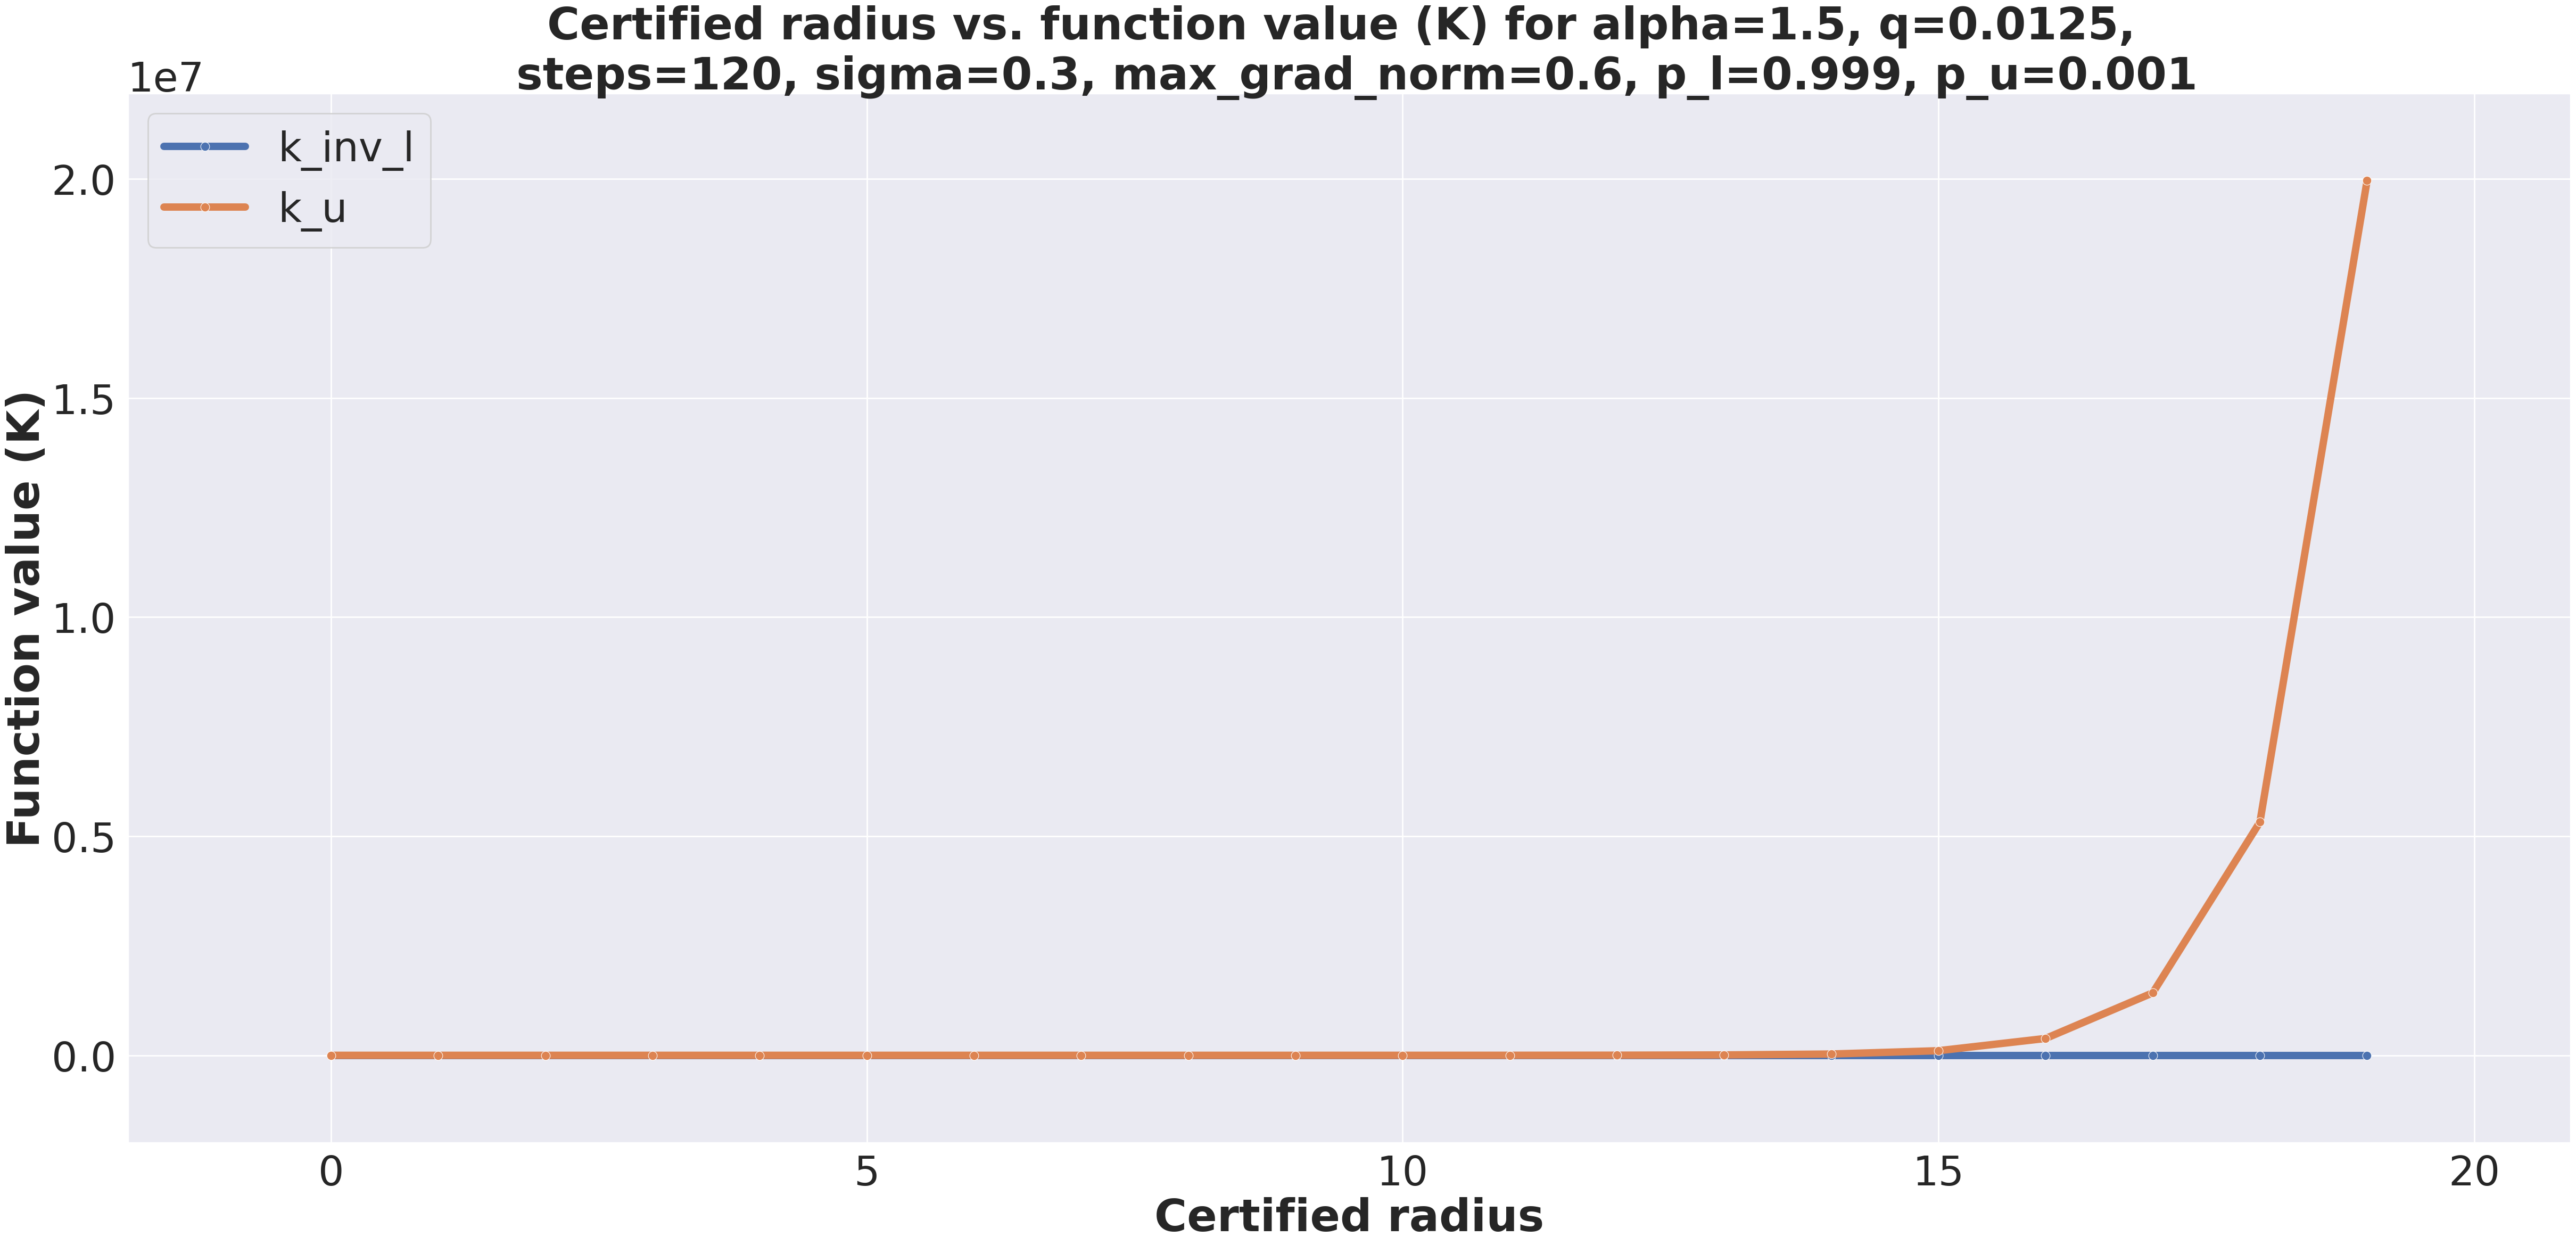

In [20]:
rs = np.arange(0, 20) # Number of changes
ks = [outcome_guarantee(q, alpha, r, steps, sigma, max_grad_norm, inside_lb, outside_ub) for r in rs]
ks = list(zip(*ks))
print(f"ks: {ks}")
k_inv_ls, k_us = np.array(list(ks[0])).squeeze(), np.array(list(ks[1])).squeeze()
make_multiline_plot(
    rs,
    np.stack((k_inv_ls, k_us)),
    ["k_inv_l", "k_u"],
    "Certified radius",
    "Function value (K)",
    f"Certified radius vs. function value (K) for alpha={alpha}, q={q}, \n steps={steps}, sigma={sigma}, max_grad_norm={max_grad_norm}, p_l={inside_lb:.3f}, p_u={outside_ub:.3f}"
)

### Antidote RDP paper source code playground